# Safety Experiment Results Visualization

This notebook visualizes the results from the safety classification experiment.
Results are loaded from JSONL files in `data/safety_experiment/`.

In [14]:
import json
from pathlib import Path
from collections import defaultdict

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Configuration

Specify which datasets, models, and conditions to include in the visualization.

In [15]:
# Base path for results
RESULTS_DIR = Path("../data/safety_experiment")

# Output directory for figures
FIGS_DIR = Path("../data/imgs")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Datasets to include (None = all available)
DATASETS = ["annotated_intents", "wildguardmix", "xstest"]

# Models to include (None = all available)
MODELS = None  # Set to None to include all models, or filter specific ones

# Conditions to include (None = all available)
CONDITIONS = [
    "vanilla_classification",
    "vanilla_generation",
    "vanilla_with_human_intent",
    "finetuned_generation",
    "finetuned_classification",
    "llamaguard_classification",
    "zeroshot_cot_classification",
    "zeroshot_cot_generation",
    "zeroshot_cot_classification_with_intent",
    "finetuned_reasoning_classification",
    "finetuned_reasoning_generation",
]

# Display names for conditions (used in all plots)
CONDITION_NAMES = {
    "vanilla_classification": "Vanilla Classification",
    "vanilla_generation": "Vanilla Generation",
    "vanilla_with_human_intent": "Vanilla + Human Intent",
    "vanilla_with_model_intent": "Vanilla + Model Intent",
    "finetuned_generation": "Fine-tuned Generation",
    "finetuned_classification": "Fine-tuned Classification",
    "llamaguard_classification": "LlamaGuard 3",
    "zeroshot_cot_classification": "CoT Classification",
    "zeroshot_cot_generation": "CoT Generation",
    "zeroshot_cot_classification_with_intent": "CoT + Human Intent",
    "finetuned_reasoning_classification": "Distilled Reasoning",
    "finetuned_reasoning_generation": "Distilled Reasoning + Intent",
}

# Display names for datasets
DATASET_NAMES = {
    "annotated_intents": "Annotated Intents",
    "wildguardmix": "WildguardTest",
    "xstest": "XSTest",
}

# Consistent color palette for conditions across all graphs (keyed by display name)
CONDITION_COLORS = {
    "Vanilla Classification": "#66c2a5",          # teal
    "Vanilla Generation": "#fc8d62",              # orange
    "Vanilla + Human Intent": "#8da0cb",          # blue
    "Vanilla + Model Intent": "#e78ac3",          # pink
    "Fine-tuned Generation": "#a6d854",           # green
    "Fine-tuned Classification": "#ffd92f",       # yellow
    "LlamaGuard 3": "#e5c494",                    # tan
    "Wildguard (reported)": "#b3b3b3",            # gray - paper baseline
    "CoT Classification": "#d73027",              # red
    "CoT Generation": "#762a83",                  # purple
    "CoT + Human Intent": "#1a9850",              # dark green
    "Distilled Reasoning": "#4393c3",             # steel blue
    "Distilled Reasoning + Intent": "#2166ac",    # dark blue
}

# Hardcoded baselines from Wildguard paper (F1 scores)
PAPER_BASELINES = {
    "WildguardTest": {"f1": 0.89, "condition": "Wildguard (reported)"},
    "XSTest": {"f1": 0.945, "condition": "Wildguard (reported)"},
}

## Load Results

In [16]:
def compute_metrics(results: list[dict]) -> dict:
    """Compute metrics from a list of result dictionaries."""
    tp = fp = tn = fn = 0

    for r in results:
        true_harm = r.get("true_harm_binary")
        pred_harm = r.get("predicted_harm")

        if true_harm is None or pred_harm is None:
            continue

        true_lower = true_harm.lower()
        pred_lower = pred_harm.lower()

        if true_lower == "harmful" and pred_lower == "harmful":
            tp += 1
        elif true_lower == "safe" and pred_lower == "harmful":
            fp += 1
        elif true_lower == "safe" and pred_lower == "safe":
            tn += 1
        elif true_lower == "harmful" and pred_lower == "safe":
            fn += 1

    total = tp + fp + tn + fn
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "total": total,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
    }


KNOWN_CONDITIONS = [
    "vanilla_classification", "vanilla_generation",
    "vanilla_with_human_intent", "vanilla_with_model_intent",
    "finetuned_generation", "finetuned_classification",
    "llamaguard_classification",
    "zeroshot_cot_classification", "zeroshot_cot_generation",
    "zeroshot_cot_classification_with_intent",
    "finetuned_reasoning_classification",
    "finetuned_reasoning_generation",
]


def load_results(results_dir: Path, datasets=None, models=None, conditions=None) -> pd.DataFrame:
    """Load all results matching the specified filters."""
    records = []

    dataset_dirs = [d for d in results_dir.iterdir() if d.is_dir()]

    for dataset_dir in dataset_dirs:
        dataset_name = dataset_dir.name

        if datasets is not None and dataset_name not in datasets:
            continue

        for jsonl_file in dataset_dir.glob("*.jsonl"):
            filename = jsonl_file.stem

            condition = None
            model_name = None
            for cond in KNOWN_CONDITIONS:
                if filename.endswith(f"_{cond}"):
                    condition = cond
                    model_name = filename[:-len(f"_{cond}")]
                    break

            if condition is None:
                continue

            if models is not None and model_name not in models:
                continue
            if conditions is not None and condition not in conditions:
                continue

            results = []
            with open(jsonl_file, "r") as f:
                for line in f:
                    results.append(json.loads(line))

            metrics = compute_metrics(results)

            display_condition = CONDITION_NAMES.get(condition, condition)
            display_dataset = DATASET_NAMES.get(dataset_name, dataset_name)

            records.append({
                "dataset": display_dataset,
                "model": model_name,
                "condition": display_condition,
                **metrics
            })

    return pd.DataFrame(records)


# Load all results
df = load_results(RESULTS_DIR, datasets=DATASETS, models=MODELS, conditions=CONDITIONS)
print(f"Loaded {len(df)} result sets")

# Llama 3.1 8B results (vanilla + finetuned conditions)
df_main = df[df["model"].str.contains("Llama-3.1", na=False)].copy()
print(f"  Llama 3.1 8B: {len(df_main)} result sets")

# Qwen3-0.6B results (includes CoT conditions)
df_qwen = df[df["model"].str.contains("Qwen3", na=False)].copy()
print(f"  Qwen3 0.6B:   {len(df_qwen)} result sets")

df

Loaded 37 result sets
  Llama 3.1 8B: 26 result sets
  Qwen3 0.6B:   8 result sets


,dataset,model,condition,accuracy,precision,recall,f1,total,tp,fp,tn,fn
0,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Distilled Reasoning + Intent,0.726744,0.703297,0.761905,0.731429,172,64,27,61,20
1,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla + Human Intent,0.690058,0.826087,0.457831,0.589147,171,38,8,80,45
2,Annotated Intents,Qwen_Qwen3-0.6B,CoT + Human Intent,0.625731,0.952381,0.240964,0.384615,171,20,1,87,63
3,Annotated Intents,Qwen_Qwen3-0.6B,CoT Classification,0.562874,0.722222,0.160494,0.262626,167,13,5,81,68
4,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Fine-tuned Classification,0.637427,0.677966,0.481928,0.563380,171,40,19,69,43
5,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla Classification,0.653061,0.697674,0.441176,0.540541,147,30,13,66,38
6,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,CoT Classification,0.604651,0.660000,0.392857,0.492537,172,33,17,71,51
7,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,CoT Generation,0.581395,0.676471,0.273810,0.389831,172,23,11,77,61
8,Annotated Intents,Qwen_Qwen3-0.6B,Vanilla Generation,0.520468,0.526316,0.120482,0.196078,171,10,9,79,73
9,Annotated Intents,Qwen_Qwen3-0.6B,Vanilla Classification,0.500000,0.250000,0.011905,0.022727,172,1,3,85,83


## F1 Score on Annotated Intents Dataset

This chart focuses on the annotated_intents dataset with bars ordered by ascending F1 score.

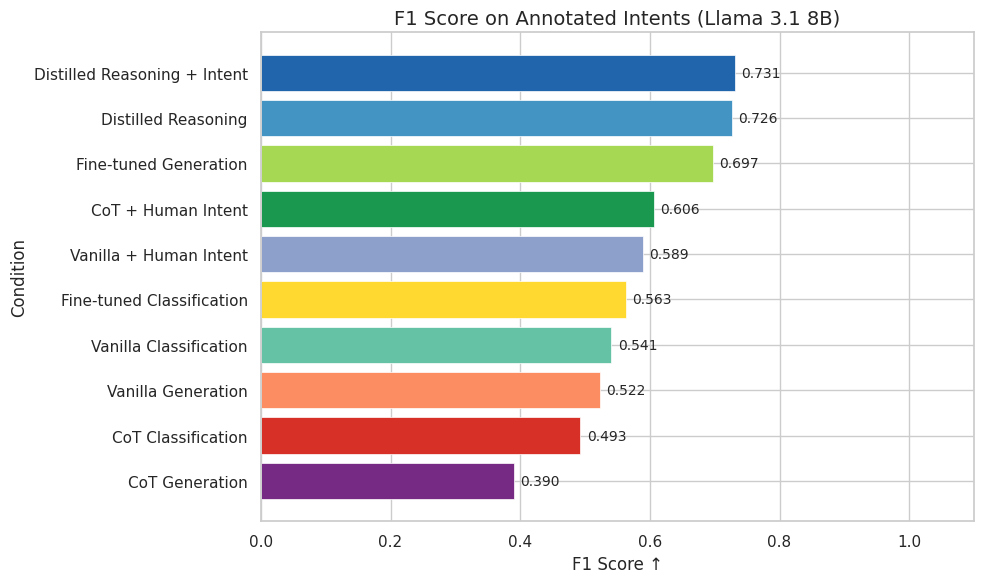

In [17]:
def plot_metric_single_dataset(df: pd.DataFrame, dataset: str, metric: str = "f1",
                                title: str = None, ascending: bool = True, save_name: str = None):
    """Plot a metric for a single dataset, ordered by the metric value."""
    df_filtered = df[df["dataset"] == dataset].copy()

    if df_filtered.empty:
        print(f"No data for dataset: {dataset}")
        return

    df_filtered = df_filtered.sort_values(metric, ascending=ascending)

    colors = [CONDITION_COLORS.get(c, "#999999") for c in df_filtered["condition"]]

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.barh(
        y=df_filtered["condition"],
        width=df_filtered[metric],
        color=colors,
        edgecolor="white",
        linewidth=0.5
    )

    for bar, val in zip(bars, df_filtered[metric]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=10)

    ax.set_xlim(0, 1.1)
    ax.set_xlabel("F1 Score ↑", fontsize=12)
    ax.set_ylabel("Condition", fontsize=12)
    ax.set_title(title or f"F1 Score on {dataset}", fontsize=14)

    plt.tight_layout()

    if save_name:
        fig.savefig(FIGS_DIR / f"{save_name}.pdf", bbox_inches="tight")

    plt.show()


# F1 for Annotated Intents — Llama 3.1 8B conditions
plot_metric_single_dataset(df_main, "Annotated Intents", metric="f1",
                           title="F1 Score on Annotated Intents (Llama 3.1 8B)", ascending=True,
                           save_name="f1_annotated_intents")

## Model Comparison on Annotated Intents

Comparing Llama 3.1 8B Instruct vs Qwen3 0.6B on the Annotated Intents dataset.

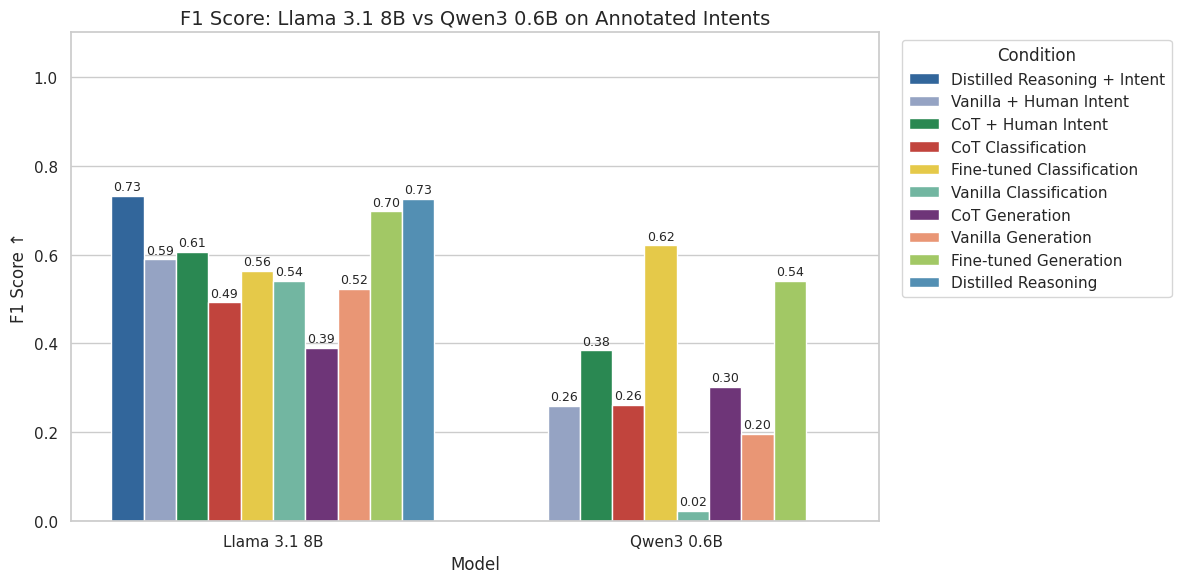

In [18]:
def plot_model_comparison(df: pd.DataFrame, dataset: str, metric: str = "f1", title: str = None, save_name: str = None):
    """Plot F1 comparison between models for a specific dataset."""
    df_plot = df[df["dataset"] == dataset].copy()

    # Exclude LlamaGuard from model comparison (dedicated baseline)
    df_plot = df_plot[df_plot["condition"] != "LlamaGuard 3"]

    if df_plot.empty:
        print(f"No data for dataset: {dataset}")
        return

    df_plot["model_short"] = df_plot["model"].apply(
        lambda x: "Llama 3.1 8B" if "Llama-3.1-8B" in x else
                  "Qwen3 0.6B" if "Qwen3-0.6B" in x else x
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    conditions_in_data = df_plot["condition"].unique()
    palette = {c: CONDITION_COLORS.get(c, "#999999") for c in conditions_in_data}

    sns.barplot(
        data=df_plot,
        x="model_short",
        y=metric,
        hue="condition",
        ax=ax,
        palette=palette
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=9, padding=2)

    ax.set_title(title or f"F1 Score by Model on {dataset}", fontsize=14)
    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("F1 Score ↑", fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    if save_name:
        fig.savefig(FIGS_DIR / f"{save_name}.pdf", bbox_inches="tight")

    plt.show()


# Compare models on Annotated Intents
plot_model_comparison(df, "Annotated Intents", metric="f1",
                      title="F1 Score: Llama 3.1 8B vs Qwen3 0.6B on Annotated Intents",
                      save_name="f1_model_comparison_annotated_intents")

## F1 Score Comparison Across All Datasets

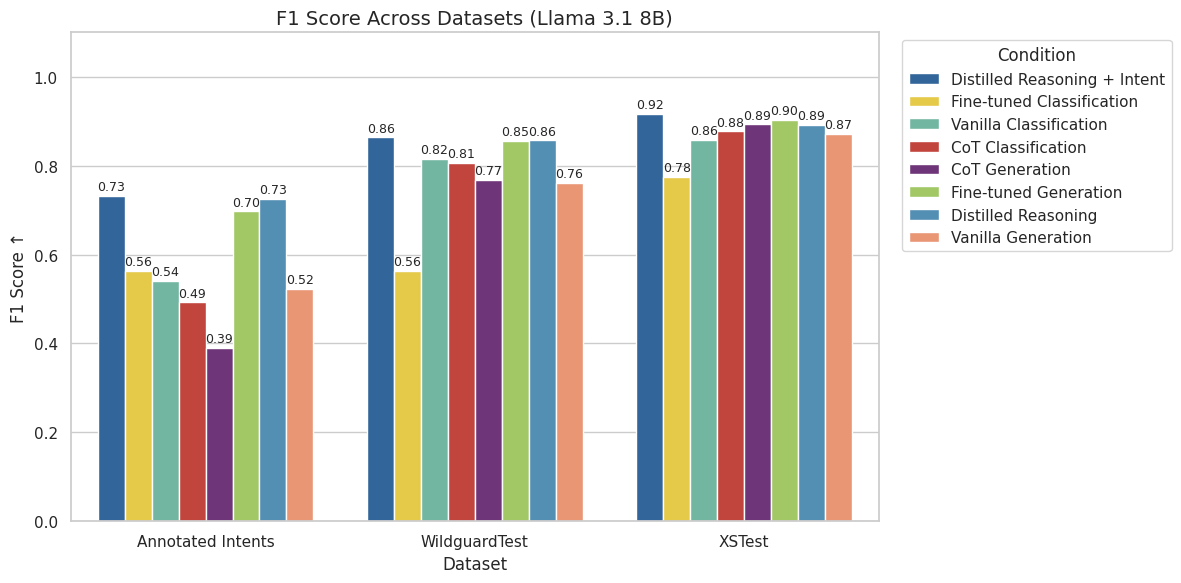

In [19]:
def plot_metric_by_dataset(df: pd.DataFrame, metric: str = "f1", exclude_conditions: list = None,
                           title: str = None, save_name: str = None):
    """Plot F1 grouped by dataset with consistent colors."""
    df_plot = df.copy()

    if exclude_conditions:
        df_plot = df_plot[~df_plot["condition"].isin(exclude_conditions)]

    if df_plot.empty:
        print("No data to plot")
        return

    fig, ax = plt.subplots(figsize=(12, 6))

    conditions_in_data = df_plot["condition"].unique()
    palette = {c: CONDITION_COLORS.get(c, "#999999") for c in conditions_in_data}

    sns.barplot(
        data=df_plot,
        x="dataset",
        y=metric,
        hue="condition",
        ax=ax,
        palette=palette
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=9, padding=2)

    ax.set_title(title or "F1 Score by Dataset", fontsize=14)
    ax.set_xlabel("Dataset", fontsize=12)
    ax.set_ylabel("F1 Score ↑", fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    if save_name:
        fig.savefig(FIGS_DIR / f"{save_name}.pdf", bbox_inches="tight")

    plt.show()


# Exclude intent-based conditions for cross-dataset comparison (not available on all datasets)
exclude = ["Vanilla + Human Intent", "Vanilla + Model Intent", "CoT + Human Intent"]

plot_metric_by_dataset(df_main, exclude_conditions=exclude,
                       title="F1 Score Across Datasets (Llama 3.1 8B)",
                       save_name="f1_comparison_all_datasets")

## Benchmark Comparison: WildguardTest and XSTest

Comparing our methods against the Wildguard paper's reported F1 scores on their benchmark datasets.

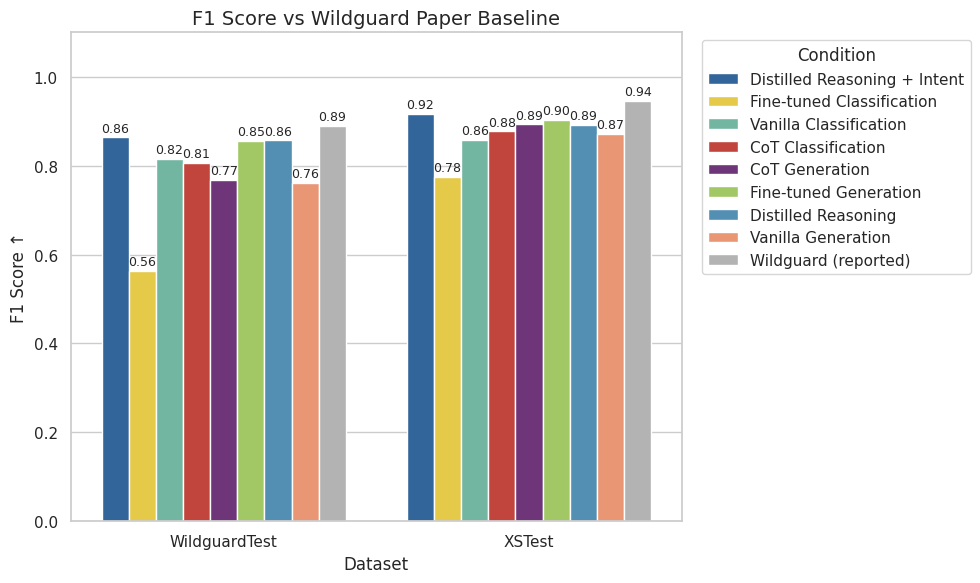

In [20]:
def plot_benchmark_comparison(df: pd.DataFrame, datasets: list, metric: str = "f1", 
                              exclude_conditions: list = None, title: str = None, save_name: str = None):
    """Plot metric comparison for specific datasets, including paper baselines."""
    metric_labels = {"f1": "F1 Score", "asr": "Attack Success Rate"}
    
    # Filter to specified datasets
    df_plot = df[df["dataset"].isin(datasets)].copy()
    
    # Filter out excluded conditions
    if exclude_conditions:
        df_plot = df_plot[~df_plot["condition"].isin(exclude_conditions)]
    
    # Add paper baselines for F1 metric
    if metric == "f1":
        baseline_rows = []
        for dataset in datasets:
            if dataset in PAPER_BASELINES:
                baseline = PAPER_BASELINES[dataset]
                baseline_rows.append({
                    "dataset": dataset,
                    "model": "paper",
                    "condition": baseline["condition"],
                    "f1": baseline["f1"],
                    "asr": None,
                })
        if baseline_rows:
            df_baselines = pd.DataFrame(baseline_rows)
            df_plot = pd.concat([df_plot, df_baselines], ignore_index=True)
    
    if df_plot.empty:
        print("No data to plot")
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Get unique conditions in the data to build palette
    conditions_in_data = df_plot["condition"].unique()
    palette = {c: CONDITION_COLORS.get(c, "#999999") for c in conditions_in_data}
    
    sns.barplot(
        data=df_plot,
        x="dataset",
        y=metric,
        hue="condition",
        ax=ax,
        palette=palette
    )
    
    # Add value labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=9, padding=2)
    
    # Direction indicators
    direction = "↓" if metric == "asr" else "↑"
    ylabel = f"{metric_labels.get(metric, metric)} {direction}"
    
    plot_title = title or f"{metric_labels.get(metric, metric)} on Benchmark Datasets"
    ax.set_title(plot_title, fontsize=14)
    ax.set_xlabel("Dataset", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")
    
    plt.tight_layout()
    
    if save_name:
        fig.savefig(FIGS_DIR / f"{save_name}.pdf", bbox_inches="tight")
    
    plt.show()


# Compare on WildguardTest and XSTest with paper baselines
benchmark_datasets = ["WildguardTest", "XSTest"]
exclude = ["Vanilla + Human Intent", "Vanilla + Model Intent"]

plot_benchmark_comparison(
    df_main, 
    datasets=benchmark_datasets, 
    metric="f1", 
    exclude_conditions=exclude,
    title="F1 Score vs Wildguard Paper Baseline",
    save_name="f1_benchmark_comparison"
)

In [21]:
# Display detailed metrics (F1-focused)
display_cols = ["dataset", "model", "condition", "f1", "precision", "recall", "total"]
df_display = df[display_cols].copy()

for col in ["f1", "precision", "recall"]:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.4f}")

df_display.sort_values(["dataset", "f1"], ascending=[True, False])

,dataset,model,condition,f1,precision,recall,total
0,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Distilled Reasoning + Intent,0.7314,0.7033,0.7619,172
14,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Distilled Reasoning,0.7261,0.7808,0.6786,172
10,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Fine-tuned Generation,0.6974,0.7681,0.6386,171
16,Annotated Intents,Qwen_Qwen3-0.6B,Fine-tuned Classification,0.6207,0.7377,0.5357,172
13,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,CoT + Human Intent,0.6061,0.8333,0.4762,172
1,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla + Human Intent,0.5891,0.8261,0.4578,171
4,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Fine-tuned Classification,0.5634,0.6780,0.4819,171
11,Annotated Intents,Qwen_Qwen3-0.6B,Fine-tuned Generation,0.5410,0.8684,0.3929,172
5,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla Classification,0.5405,0.6977,0.4412,147
17,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla Generation,0.5224,0.6481,0.4375,167


## Reasoning Distillation: Comparison Across All Benchmarks

Comparing the plain fine-tuned generation baseline against the two distilled reasoning conditions (MODE D: reasoning + harm; MODE E: reasoning + intent + harm) across all three datasets.

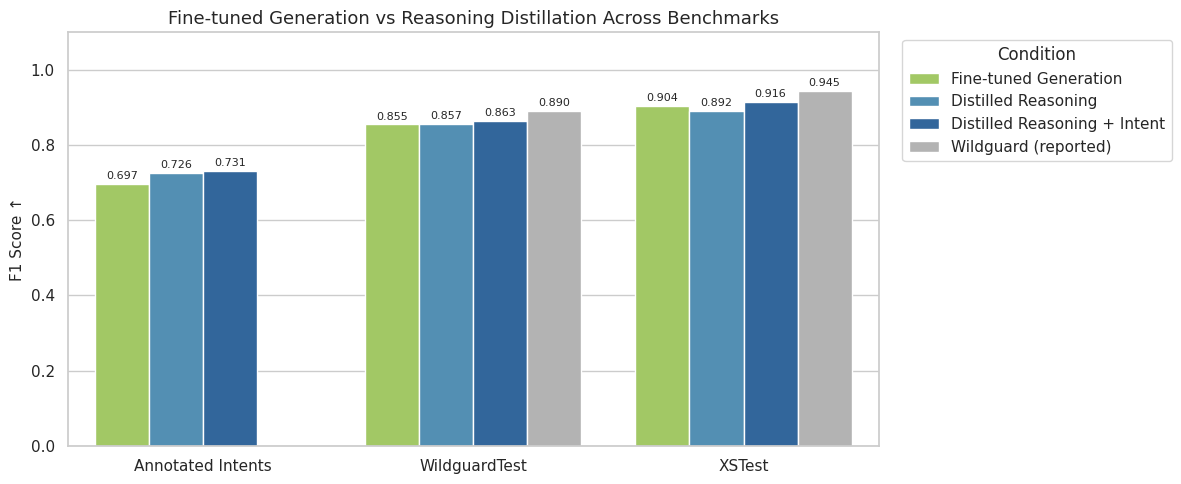

In [22]:
REASONING_CONDITIONS = [
    "Fine-tuned Generation",
    "Distilled Reasoning",
    "Distilled Reasoning + Intent",
]

df_reasoning = df_main[df_main["condition"].isin(REASONING_CONDITIONS)].copy()

# Add Wildguard paper baselines for WildguardTest and XSTest
baseline_rows = [
    {"dataset": ds, "model": "paper", "condition": info["condition"], "f1": info["f1"]}
    for ds, info in PAPER_BASELINES.items()
]
df_plot = pd.concat([df_reasoning, pd.DataFrame(baseline_rows)], ignore_index=True)

all_conditions = REASONING_CONDITIONS + ["Wildguard (reported)"]
palette = {c: CONDITION_COLORS.get(c, "#999999") for c in all_conditions}

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=df_plot,
    x="dataset",
    y="f1",
    hue="condition",
    hue_order=all_conditions,
    palette=palette,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

ax.set_title(
    "Fine-tuned Generation vs Reasoning Distillation Across Benchmarks",
    fontsize=13,
)
ax.set_xlabel("")
ax.set_ylabel("F1 Score ↑", fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
fig.savefig(FIGS_DIR / "f1_reasoning_distillation_comparison.pdf", bbox_inches="tight")
plt.show()

## Reasoning Length Analysis

How long are the reasoning traces generated by each condition that produces a `reasoning` field?
This covers the distilled models (MODE D/E) and the zero-shot CoT baselines.
Length is measured in words.

In [23]:
REASONING_CONDITIONS_RAW = [
    "zeroshot_cot_classification",
    "zeroshot_cot_generation",
    "finetuned_reasoning_classification",
    "finetuned_reasoning_generation",
]


def load_reasoning_lengths(results_dir: Path, datasets=None) -> pd.DataFrame:
    """Load raw reasoning fields and compute word-count lengths."""
    rows = []
    for dataset_dir in results_dir.iterdir():
        if not dataset_dir.is_dir():
            continue
        dataset_name = dataset_dir.name
        if datasets is not None and dataset_name not in datasets:
            continue

        for jsonl_file in dataset_dir.glob("*.jsonl"):
            filename = jsonl_file.stem
            condition = None
            for cond in REASONING_CONDITIONS_RAW:
                if filename.endswith(f"_{cond}"):
                    condition = cond
                    break
            if condition is None:
                continue

            with open(jsonl_file) as f:
                for line in f:
                    rec = json.loads(line)
                    reasoning = rec.get("reasoning") or ""
                    rows.append({
                        "dataset": DATASET_NAMES.get(dataset_name, dataset_name),
                        "condition": CONDITION_NAMES.get(condition, condition),
                        "reasoning_words": len(reasoning.split()),
                    })

    return pd.DataFrame(rows)


df_lengths = load_reasoning_lengths(RESULTS_DIR, datasets=DATASETS)
print(f"Loaded {len(df_lengths)} reasoning records")

# Summary statistics
df_lengths.groupby("condition")["reasoning_words"].describe().round(1)

Loaded 9628 reasoning records


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
CoT Classification,2493.0,108.1,74.2,6.0,77.0,96.0,122.0,1552.0
CoT Generation,2493.0,67.3,45.0,6.0,47.0,60.0,80.0,1594.0
Distilled Reasoning,2321.0,101.2,37.7,36.0,70.0,94.0,130.0,254.0
Distilled Reasoning + Intent,2321.0,109.7,43.5,43.0,75.0,100.0,140.0,353.0
